<a href="https://colab.research.google.com/github/AnindyaNaura12/Data-Mining/blob/main/LatihanModul5.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
!pip install mlxtend

In [4]:
import warnings
warnings.filterwarnings("ignore")

import pandas as pd
from mlxtend.preprocessing import TransactionEncoder
from mlxtend.frequent_patterns import apriori, association_rules

In [5]:
from google.colab import files
uploaded = files.upload()

Saving GroceryStoreDataSet.csv to GroceryStoreDataSet.csv


In [8]:
df = pd.read_csv("GroceryStoreDataSet.csv")
print(df)

                MILK,BREAD,BISCUIT
0    BREAD,MILK,BISCUIT,CORNFLAKES
1              BREAD,TEA,BOURNVITA
2             JAM,MAGGI,BREAD,MILK
3                MAGGI,TEA,BISCUIT
4              BREAD,TEA,BOURNVITA
5             MAGGI,TEA,CORNFLAKES
6          MAGGI,BREAD,TEA,BISCUIT
7              JAM,MAGGI,BREAD,TEA
8                       BREAD,MILK
9   COFFEE,COCK,BISCUIT,CORNFLAKES
10  COFFEE,COCK,BISCUIT,CORNFLAKES
11          COFFEE,SUGER,BOURNVITA
12               BREAD,COFFEE,COCK
13             BREAD,SUGER,BISCUIT
14         COFFEE,SUGER,CORNFLAKES
15           BREAD,SUGER,BOURNVITA
16              BREAD,COFFEE,SUGER
17              BREAD,COFFEE,SUGER
18      TEA,MILK,COFFEE,CORNFLAKES


In [13]:
transactions = df.iloc[:,0].apply(lambda x: x.split(','))

print(transactions)

0      [BREAD, MILK, BISCUIT, CORNFLAKES]
1                 [BREAD, TEA, BOURNVITA]
2               [JAM, MAGGI, BREAD, MILK]
3                   [MAGGI, TEA, BISCUIT]
4                 [BREAD, TEA, BOURNVITA]
5                [MAGGI, TEA, CORNFLAKES]
6            [MAGGI, BREAD, TEA, BISCUIT]
7                [JAM, MAGGI, BREAD, TEA]
8                           [BREAD, MILK]
9     [COFFEE, COCK, BISCUIT, CORNFLAKES]
10    [COFFEE, COCK, BISCUIT, CORNFLAKES]
11             [COFFEE, SUGER, BOURNVITA]
12                  [BREAD, COFFEE, COCK]
13                [BREAD, SUGER, BISCUIT]
14            [COFFEE, SUGER, CORNFLAKES]
15              [BREAD, SUGER, BOURNVITA]
16                 [BREAD, COFFEE, SUGER]
17                 [BREAD, COFFEE, SUGER]
18        [TEA, MILK, COFFEE, CORNFLAKES]
Name: MILK,BREAD,BISCUIT, dtype: object


In [17]:
te = TransactionEncoder()
te_array = te.fit(transactions).transform(transactions)

df_encoded = pd.DataFrame(te_array, columns=te.columns_)

df_encoded.head()

,BISCUIT,BOURNVITA,BREAD,COCK,COFFEE,CORNFLAKES,JAM,MAGGI,MILK,SUGER,TEA
0,True,False,True,False,False,True,False,False,True,False,False
1,False,True,True,False,False,False,False,False,False,False,True
2,False,False,True,False,False,False,True,True,True,False,False
3,True,False,False,False,False,False,False,True,False,False,True
4,False,True,True,False,False,False,False,False,False,False,True


In [20]:
frequent_items = apriori(df_encoded, min_support=0.2, use_colnames=True)
frequent_items

,support,itemsets
0,0.315789,(BISCUIT)
1,0.210526,(BOURNVITA)
2,0.631579,(BREAD)
3,0.421053,(COFFEE)
4,0.315789,(CORNFLAKES)
5,0.263158,(MAGGI)
6,0.210526,(MILK)
7,0.315789,(SUGER)
8,0.368421,(TEA)
9,0.210526,"(BREAD, SUGER)"


In [22]:
rules = association_rules(frequent_items, metric="confidence", min_threshold=0.4)
rules

,antecedents,consequents,antecedent support,consequent support,support,confidence,lift,representativity,leverage,conviction,zhangs_metric,jaccard,certainty,kulczynski
0,(SUGER),(BREAD),0.315789,0.631579,0.210526,0.666667,1.055556,1.0,0.011080,1.105263,0.076923,0.285714,0.095238,0.500000
1,(TEA),(BREAD),0.368421,0.631579,0.210526,0.571429,0.904762,1.0,-0.022161,0.859649,-0.142857,0.266667,-0.163265,0.452381
2,(CORNFLAKES),(COFFEE),0.315789,0.421053,0.210526,0.666667,1.583333,1.0,0.077562,1.736842,0.538462,0.400000,0.424242,0.583333
3,(COFFEE),(CORNFLAKES),0.421053,0.315789,0.210526,0.500000,1.583333,1.0,0.077562,1.368421,0.636364,0.400000,0.269231,0.583333
4,(COFFEE),(SUGER),0.421053,0.315789,0.210526,0.500000,1.583333,1.0,0.077562,1.368421,0.636364,0.400000,0.269231,0.583333
5,(SUGER),(COFFEE),0.315789,0.421053,0.210526,0.666667,1.583333,1.0,0.077562,1.736842,0.538462,0.400000,0.424242,0.583333
6,(MAGGI),(TEA),0.263158,0.368421,0.210526,0.800000,2.171429,1.0,0.113573,3.157895,0.732143,0.500000,0.683333,0.685714
7,(TEA),(MAGGI),0.368421,0.263158,0.210526,0.571429,2.171429,1.0,0.113573,1.719298,0.854167,0.500000,0.418367,0.685714


In [23]:
rules[['antecedents', 'consequents', 'support', 'confidence', 'lift']]

,antecedents,consequents,support,confidence,lift
0,(SUGER),(BREAD),0.210526,0.666667,1.055556
1,(TEA),(BREAD),0.210526,0.571429,0.904762
2,(CORNFLAKES),(COFFEE),0.210526,0.666667,1.583333
3,(COFFEE),(CORNFLAKES),0.210526,0.500000,1.583333
4,(COFFEE),(SUGER),0.210526,0.500000,1.583333
5,(SUGER),(COFFEE),0.210526,0.666667,1.583333
6,(MAGGI),(TEA),0.210526,0.800000,2.171429
7,(TEA),(MAGGI),0.210526,0.571429,2.171429


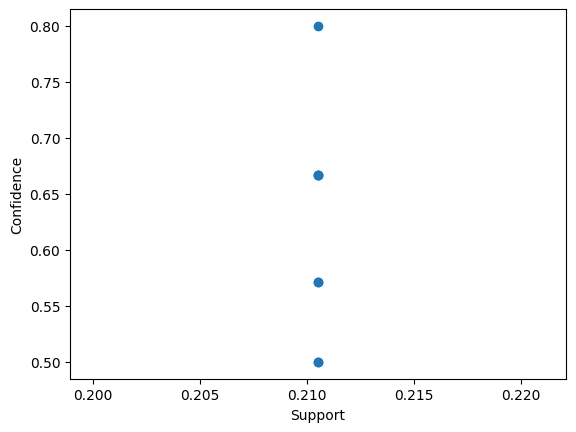

In [25]:
import matplotlib.pyplot as plt

plt.scatter(rules['support'], rules['confidence'])
plt.xlabel('Support')
plt.ylabel('Confidence')
plt.show()